In [6]:
import pandas as pd

# URL to the raw Iris dataset (hosted on UCI Machine Learning Repository)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Define the column names since the raw CSV doesn't have a header row
column_names = ['sepal_length', 'SepalWidthCm', 'PetalLengthCm', 'petal_width', 'Species']

# Read the dataset directly from the URL
df = pd.read_csv(url, names=column_names)

# Display the first few rows to verify
df.head()

,sepal_length,SepalWidthCm,PetalLengthCm,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,sepal_length,SepalWidthCm,PetalLengthCm,petal_width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


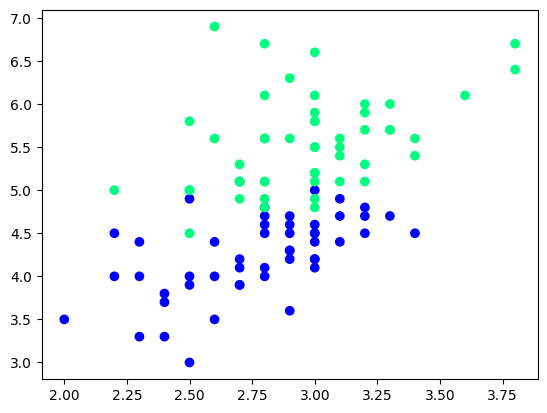

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [10]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
78,2.9,4.5,1
58,2.9,4.6,1
71,2.8,4.0,1
107,2.9,6.3,2
56,3.3,4.7,1
79,2.6,3.5,1
101,2.7,5.1,2
92,2.6,4.0,1
94,2.7,4.2,1
95,3.0,4.2,1


In [11]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)
df_train

,SepalWidthCm,PetalLengthCm,Species
75,3.0,4.4,1
129,3.0,5.8,2
98,2.5,3.0,1
59,2.7,3.9,1
81,2.4,3.7,1
78,2.9,4.5,1
76,2.8,4.8,1
80,2.4,3.8,1
131,3.8,6.4,2
90,2.6,4.4,1


In [12]:
df_val

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
96,2.9,4.2,1
64,2.9,3.6,1
94,2.7,4.2,1
72,2.5,4.9,1


In [13]:
df_test

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
148,3.4,5.4,2
127,3.0,4.9,2
139,3.1,5.4,2
145,3.0,5.2,2


In [14]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values
y_test

array([1, 1, 1, 1, 1])

# BAGGING

In [15]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
75,3.0,4.4,1
98,2.5,3.0,1
81,2.4,3.7,1
76,2.8,4.8,1
80,2.4,3.8,1
129,3.0,5.8,2
80,2.4,3.8,1
78,2.9,4.5,1


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

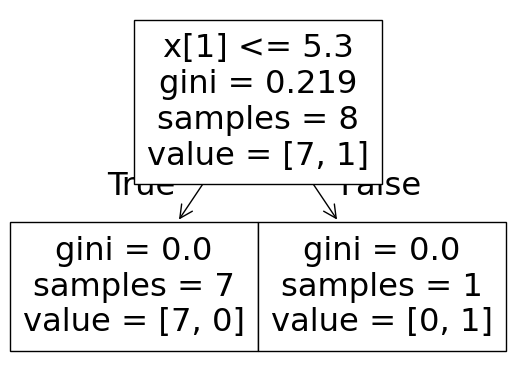

1.0


d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


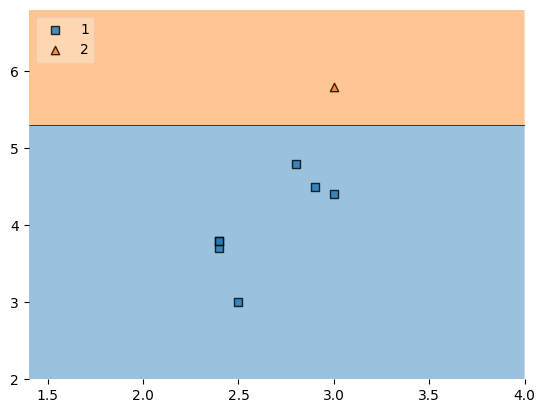

In [17]:

dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)

In [18]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
129,3.0,5.8,2
98,2.5,3.0,1
98,2.5,3.0,1
131,3.8,6.4,2
129,3.0,5.8,2
78,2.9,4.5,1
59,2.7,3.9,1
90,2.6,4.4,1


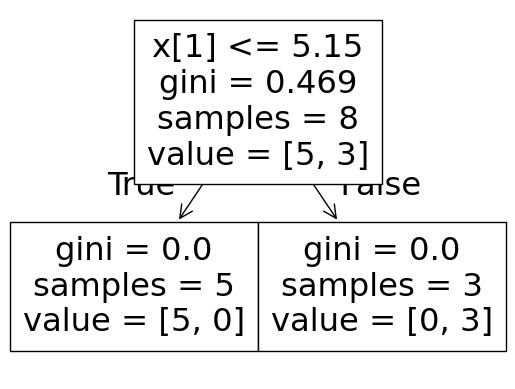

1.0


d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


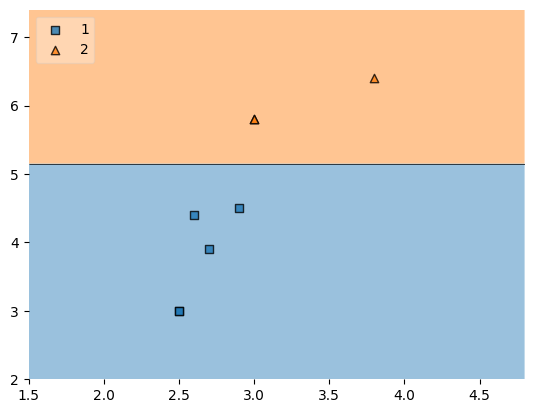

In [19]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [20]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
90,2.6,4.4,1
131,3.8,6.4,2
78,2.9,4.5,1
98,2.5,3.0,1
81,2.4,3.7,1
90,2.6,4.4,1
81,2.4,3.7,1
75,3.0,4.4,1


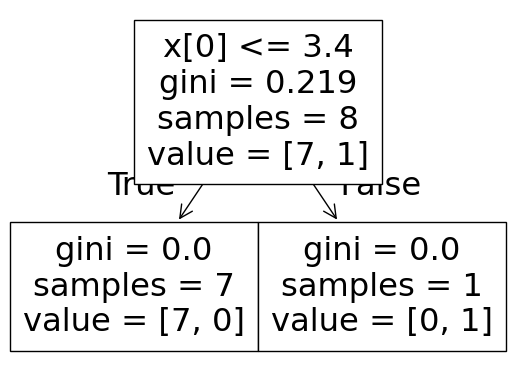

1.0


d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


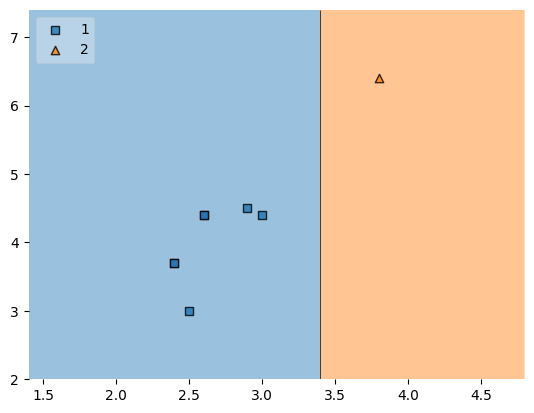

In [21]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# PREDICT

In [22]:
df_test

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
148,3.4,5.4,2
127,3.0,4.9,2
139,3.1,5.4,2
145,3.0,5.2,2


In [23]:
import numpy as np
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# PASTING

In [24]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
75,3.0,4.4,1
129,3.0,5.8,2
98,2.5,3.0,1
59,2.7,3.9,1
81,2.4,3.7,1
78,2.9,4.5,1
76,2.8,4.8,1
80,2.4,3.8,1
131,3.8,6.4,2
90,2.6,4.4,1


In [25]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
59,2.7,3.9,1
131,3.8,6.4,2
90,2.6,4.4,1
78,2.9,4.5,1
80,2.4,3.8,1
81,2.4,3.7,1
98,2.5,3.0,1
129,3.0,5.8,2


# RANDOM SUBSPACES

In [27]:
df1 = pd.read_csv(url, names=column_names)
df1 = df1.sample(10)
df1

,sepal_length,SepalWidthCm,PetalLengthCm,petal_width,Species
127,6.1,3.0,4.9,1.8,Iris-virginica
54,6.5,2.8,4.6,1.5,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
123,6.3,2.7,4.9,1.8,Iris-virginica
55,5.7,2.8,4.5,1.3,Iris-versicolor
15,5.7,4.4,1.5,0.4,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica
37,4.9,3.1,1.5,0.1,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor


In [28]:
df1.sample(2,replace=True,axis=1)

,petal_width,PetalLengthCm
127,1.8,4.9
54,1.5,4.6
71,1.3,4.0
123,1.8,4.9
55,1.3,4.5
15,0.4,1.5
120,2.3,5.7
37,0.1,1.5
2,0.2,1.3
98,1.1,3.0


# RANDOM PATCHES

In [29]:
df1

,sepal_length,SepalWidthCm,PetalLengthCm,petal_width,Species
127,6.1,3.0,4.9,1.8,Iris-virginica
54,6.5,2.8,4.6,1.5,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
123,6.3,2.7,4.9,1.8,Iris-virginica
55,5.7,2.8,4.5,1.3,Iris-versicolor
15,5.7,4.4,1.5,0.4,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica
37,4.9,3.1,1.5,0.1,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor


In [30]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,petal_width,petal_width
2,0.2,0.2
37,0.1,0.1
123,1.8,1.8
127,1.8,1.8
98,1.1,1.1
54,1.5,1.5
98,1.1,1.1
123,1.8,1.8
